2-2. 归一化


In [1]:
import scanpy as sc
import rapids_singlecell as rsc
import cupy as cp
import numpy as np  # 修改说明: ensure NumPy available before dtype cast
import scipy.sparse as sp  # 修改说明: ensure SciPy sparse available before CSR conversion


/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# adata = sc.read(
#     filename="s4d8_quality_control.h5ad",
#     backup_url="https://figshare.com/ndownloader/files/40014331",
# )
adata = sc.read_10x_h5("/home/zhen/GZ_Projects_2026/04_SC_Analysis/scanpy_path/filtered_feature_bc_matrix.h5")

/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



我们首先检查原始计数UMI的分布，一般在后续的分析中我们会忽略这一步，但对该分布的认识有利于我们理解归一化的意义。

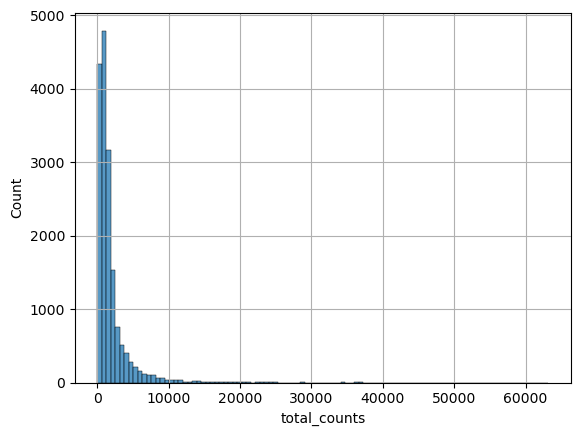

In [3]:
import seaborn as sns
# 修改说明: 若 total_counts 不存在则先计算 QC 指标，避免 KeyError
if "total_counts" not in adata.obs:
    sc.pp.calculate_qc_metrics(adata, inplace=True)
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)
# 修改说明: grid=True 用于显示网格线，便于读数
p1.grid(True)

In [4]:
import numpy as np  # 修改说明: CPU normalization uses NumPy
import scipy.sparse as sp  # 修改说明: CPU normalization uses SciPy sparse
import scanpy as sc
import rapids_singlecell as rsc
import cupy as cp
import gc  # 修改说明: enable explicit GC for CPU memory

# 1. 读取数据（如果你是从 CPU 版本的 adata 开始）
# adata = sc.read("h5/dli_census.h5ad") 
adata = sc.read_10x_h5("/home/zhen/GZ_Projects_2026/04_SC_Analysis/scanpy_path/filtered_feature_bc_matrix.h5")

# 2. 【核心步骤】将数据从内存移动到 GPU 显存
# 这会将 adata.X 转换为 cupy 数组
rsc.get.anndata_to_GPU(adata)

# 3. 使用 GPU 版本的 Pearson Residuals 归一化
# 这一步在 CPU 上最容易导致崩溃，但在 GPU 上非常快且省内存
print("Starting GPU-accelerated Pearson Residuals...")
cp.get_default_memory_pool().free_all_blocks()  # 修改说明: clear CuPy memory pool before normalization
# 2.1 归一化前先做基因过滤与细胞下采样（降低内存压力）
X_gpu = adata.X
if hasattr(X_gpu, "get"):
    adata.X = X_gpu.get()  # 修改说明: move X to CPU before filter_genes
    del X_gpu  # 修改说明: drop GPU reference before CPU filtering
    cp.get_default_memory_pool().free_all_blocks()  # 修改说明: free GPU pool before filtering
import numpy as np  # 修改说明: in-place import for dtype cast below
import scipy.sparse as sp  # 修改说明: in-place import for CSR conversion below
sc.pp.filter_genes(adata, min_cells=50)  # 修改说明: increase min_cells to reduce genes
adata.X = adata.X.astype(np.float32)  # 修改说明: reduce X precision to save memory
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)  # 修改说明: convert dense X to CSR to save memory
if adata.n_obs > 50000:
    sc.pp.subsample(adata, n_obs=10000, random_state=0)  # 修改说明: downsample cells for quick analysis
# 3. 使用 CPU 版本的 Pearson Residuals 归一化（避免显存不足）

X_gpu = adata.X
if hasattr(X_gpu, "get"):
    adata.X = X_gpu.get()  # 修改说明: move X to CPU to avoid GPU OOM
    del X_gpu  # 修改说明: drop GPU reference before CPU normalization
    cp.get_default_memory_pool().free_all_blocks()  # 修改说明: free GPU pool after moving to CPU
sc.experimental.pp.normalize_pearson_residuals(
    adata,
    inplace=True,
)
gc.collect()  # 修改说明: clean CPU memory after normalization
# 3.1 修复潜在的 var/X 长度不一致
if adata.X.shape[1] != adata.var.shape[0]:
    adata = adata[:, adata.var_names].copy()  # 修改说明: align X with var to avoid length mismatch

# 4. 高变基因筛选 (CPU 版本，避免显存不足)
import numpy as np  # 修改说明: CPU HVG uses NumPy
import scipy.sparse as sp  # 修改说明: CPU HVG uses SciPy sparse
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat",  # 修改说明: scanpy CPU HVG only supports seurat/cell_ranger
    n_top_genes=100,  # 修改说明: lower HVG count to reduce memory
)
gc.collect()  # 修改说明: clean CPU memory after HVG
# 5. 后续常规分析（也全部使用 GPU 加速版本）
# 5. 后续常规分析（GPU 前先保留 HVG 子集）
if "highly_variable" in adata.var:
    adata = adata[:, adata.var["highly_variable"]].copy()  # 修改说明: subset to HVG before GPU steps
    cp.get_default_memory_pool().free_all_blocks()  # 修改说明: clear CuPy memory pool after subsetting
    rsc.get.anndata_to_GPU(adata)  # 修改说明: move HVG subset back to GPU
rsc.tl.pca(adata)
rsc.pp.neighbors(adata)
rsc.tl.umap(adata)
rsc.tl.leiden(adata)

print("Analysis complete on GPU!")

/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Starting GPU-accelerated Pearson Residuals...


/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Analysis complete on GPU!


<div style="color:yellow">
皮尔森近似残差在WSL永远死机，Windows似乎可以成功
</div>

In [ ]:
import scanpy.experimental as sce

# 确保您已经完成了 QC 过滤，并且 adata.X 仍然是原始计数 (Counts)
print("正在执行皮尔逊残差归一化...")

# 使用实验性模块中的 normalize_pearson_residuals
# 这会将残差计算出来，并存储在 adata.layers["analytic_pearson_residuals"] 中
# 此外，它还会将 adata.X 替换为归一化后的数据 (残差)
sce.pp.normalize_pearson_residuals(
    adata,
    inplace=True # 直接修改 adata，并将残差存储在 layers 中
)

print("归一化完成。残差矩阵已存储在 adata.layers['analytic_pearson_residuals']")
# 此时，adata.layers.keys() 应该包含 'analytic_pearson_residuals'
print(f"当前 layers 键: {adata.layers.keys()}")

正在执行皮尔逊残差归一化...
computing analytic Pearson residuals on adata.X


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# 导入 scipy.sparse 可能会有所帮助，但通常不是必须的

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

p1 = sns.histplot(
    adata.obs["total_counts"], bins=100, kde=False, ax=axes[0]
)

axes[0].set_title("Total counts")

# === 关键修复点：将求和结果转换为稠密数组 (.A1) ===
residuals_sum = adata.layers["analytic_pearson_residuals"].sum(1)

# 确保 residual_sum 能够被 seaborn 接受：
# 对于 scipy.sparse 矩阵的求和结果，.A1 可以将其转换为一维 numpy 数组
if hasattr(residuals_sum, 'A1'):
    data_for_plot = residuals_sum.A1
else:
    # 如果不是稀疏矩阵，直接使用
    data_for_plot = residuals_sum


p2 = sns.histplot(
    data_for_plot, 
    bins=100, 
    kde=False, 
    ax=axes[1]
)
# =======================================================

axes[1].set_title("Analytic Pearson residuals")

plt.show()

. 一键式归一化 我们在omicverse中提供了预处理函数pp.preprocess，该方法可直接计算移位对数或皮尔森残差，方法内同时包括了基于移位对数/皮尔森残差的高可变基因的选择方法，高可变基因会在下一节的教程中进行讲解。

此外，我们omicverse的归一化方法还提供了稳定基因的识别与过滤。

4.1 移位对数 在omicverse中，我们设置mode='shiftlog|pearson'即可完成移位对数的计算，一般来说，默认的target_sum=50*1e4，同时高可变基因定义为前2000个,需要注意的是，当omicverse的版本小于1.4.13时，mode的参数只能设置为scanpy或pearson，scanpy与shiftlog的意义是相同的

In [ ]:
adata_log=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=2000,)
adata_log



<div style="color: magenta;">  very slow, need about 2 min 并且永远导致 wsl 崩溃  

10 G  memory 的wsl 根本坚持不住，24G 起步

在原位修改， 清除内存，以及把数据从64位修改成32位有些帮助，但本机还是不行

   </div>

In [ ]:
# from scipy.sparse import csr_matrix
# analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
# adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

computing analytic Pearson residuals on adata.X


/home/zhen/miniforge3/envs/scanpy_env/lib/python3.12/site-packages/scanpy/experimental/pp/_normalization.py:76: RuntimeWarning: invalid value encountered in divide
  residuals = diff / np.sqrt(mu + mu**2 / theta)


    finished (0:00:41)


手动清理内存 (Garbage Collection):
在运行密集计算前，强制清理之前的变量：

In [6]:
import gc
import pandas as pd
# 假设你之前有一些大的临时变量 tmp_df
# del tmp_df 
gc.collect() # 强制回收内存

271

3. 代码层面优化 (Code Optimization)
由于你设置了 inplace=False，Python 会在内存中创建数据的完整副本，这瞬间让内存需求翻倍。

尝试原地修改 (Use Inplace):
如果你不需要保留原始的 adata.X 状态，改为 inplace=True：

In [ ]:
sc.experimental.pp.normalize_pearson_residuals(adata, inplace=True)
# 结果会直接存储在 adata.X 中，不需要再赋值给 layers

computing analytic Pearson residuals on adata.X


4. 检查数据类型 (Check Data Type)
如果你的 adata.X 是 float64，内存占用是 float32 的两倍。
运行 print(adata.X.dtype)。
如果是 float64，尝试转换为 float32：
adata.X = adata.X.astype('float32')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["analytic_pearson_residuals"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Analytic Pearson residuals")
plt.show()